<a href="https://colab.research.google.com/github/ltd03112007-lab/BTVN/blob/main/2_14ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.0 MB/s eta 0:00:00


NOOTC: 50.00
delivery_priority: 50.00


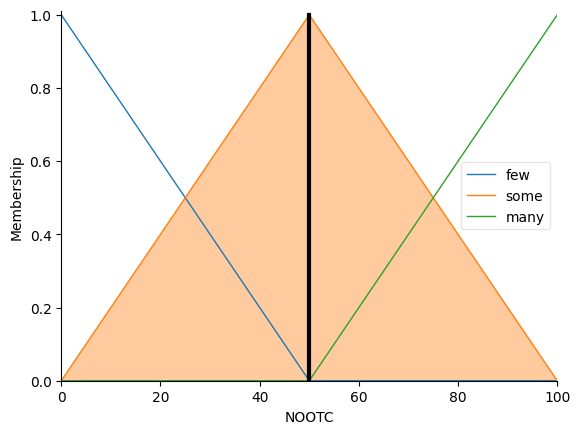

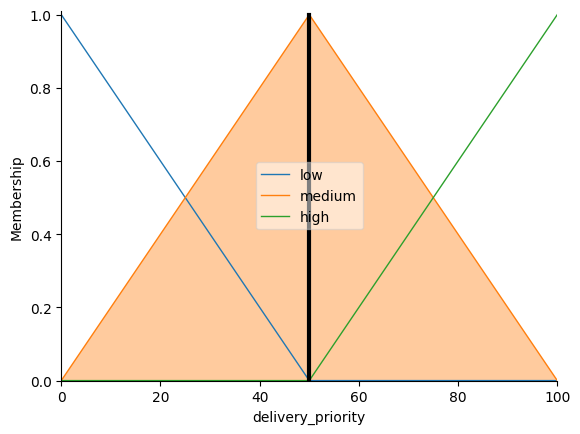

In [9]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

order_density=ctrl.Antecedent(np.arange(0,101,1), 'order_density')
order_density['low']=fuzz.trimf(order_density.universe, [0,0,50])
order_density['medium']=fuzz.trimf(order_density.universe, [0,50,100])
order_density['high']=fuzz.trimf(order_density.universe, [50,100,100])

delivery_agency=ctrl.Antecedent(np.arange(0,101,1), 'delivery_agency')
delivery_agency['low']=fuzz.trimf(delivery_agency.universe, [0,0,50])
delivery_agency['medium']=fuzz.trimf(delivery_agency.universe, [0,50,100])
delivery_agency['high']=fuzz.trimf(delivery_agency.universe, [50,100,100])

current_load=ctrl.Antecedent(np.arange(0,101,1), 'current_load')
current_load['low']=fuzz.trimf(current_load.universe, [0,0,50])
current_load['medium']=fuzz.trimf(current_load.universe, [0,50,100])
current_load['high']=fuzz.trimf(current_load.universe, [50,100,100])

traffic_condition=ctrl.Antecedent(np.arange(0,101,1),'traffic_condition')
traffic_condition['low']=fuzz.trimf(traffic_condition.universe, [0,0,50])
traffic_condition['medium']=fuzz.trimf(traffic_condition.universe, [0,50,100])
traffic_condition['high']=fuzz.trimf(traffic_condition.universe, [50,100,100])

profit_per_delivery=ctrl.Antecedent(np.arange(0,101,1), 'profit_per_delivery')
profit_per_delivery['low']=fuzz.trimf(profit_per_delivery.universe, [0,0,50])
profit_per_delivery['medium']=fuzz.trimf(profit_per_delivery.universe, [0,50,100])
profit_per_delivery['high']=fuzz.trimf(profit_per_delivery.universe, [50,100,100])

NOOTC= ctrl.Consequent(np.arange(0,101,1),'NOOTC')
NOOTC['few']=fuzz.trimf(NOOTC.universe, [0,0,50])
NOOTC['some']=fuzz.trimf(NOOTC.universe, [0,50,100])
NOOTC['many']=fuzz.trimf(NOOTC.universe, [50,100,100])

delivery_priority=ctrl.Consequent(np.arange(0,101,1), 'delivery_priority')
delivery_priority['low']=fuzz.trimf(delivery_priority.universe, [0,0,50])
delivery_priority['medium']=fuzz.trimf(delivery_priority.universe, [0,50,100])
delivery_priority['high']=fuzz.trimf(delivery_priority.universe, [50,100,100])

rule1=ctrl.Rule(order_density['high']&current_load['low']&traffic_condition['low'], NOOTC['many'])
rule2=ctrl.Rule(order_density['medium']&traffic_condition['high']&delivery_agency['medium'], NOOTC['few'])
rule3=ctrl.Rule(order_density['high']&current_load['high']&profit_per_delivery['medium'], NOOTC['some'])
rule4=ctrl.Rule(order_density['low']&delivery_agency['high']&traffic_condition['medium'], NOOTC['few'])
rule5=ctrl.Rule(delivery_agency['high']&traffic_condition['high']&profit_per_delivery['high'], NOOTC['few'])
rule9=ctrl.Rule(order_density['high']&delivery_agency['medium']&traffic_condition['medium'], NOOTC['some'])
rule10=ctrl.Rule(order_density['low']&current_load['medium']&profit_per_delivery['low'], NOOTC['few'])
rule11=ctrl.Rule(order_density['high']&current_load['low']&profit_per_delivery['medium'], NOOTC['some'])
rule13=ctrl.Rule(order_density['medium']&current_load['low']&profit_per_delivery['medium'], NOOTC['few'])

rule6=ctrl.Rule(delivery_agency['high']&profit_per_delivery['high'], delivery_priority['high'])
rule7=ctrl.Rule(delivery_agency['medium']&traffic_condition['medium'], delivery_priority['medium'])
rule8=ctrl.Rule(delivery_agency['low']&order_density['high']&profit_per_delivery['low'], delivery_priority['low'])

control_system=ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule9,rule10,rule11,rule13,rule6,rule7,rule8])
delivery_system=ctrl.ControlSystemSimulation(control_system)
delivery_system.input['order_density']=100
delivery_system.input['delivery_agency']=50
delivery_system.input['current_load']=0
delivery_system.input['traffic_condition']=50
delivery_system.input['profit_per_delivery']=50
delivery_system.compute()
print(f'NOOTC: {delivery_system.output["NOOTC"]:.2f}')
print(f'delivery_priority: {delivery_system.output["delivery_priority"]:.2f}')
NOOTC.view(sim=delivery_system)
delivery_priority.view(sim=delivery_system)